W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Используем файл: dns.cap
DNS записей найдено: 38


,time,domain,src_ip,dst_ip
0,2005-03-30 08:47:46.496046,google.com,192.168.170.8,192.168.170.20
1,2005-03-30 08:47:46.496576,google.com,192.168.170.20,192.168.170.8
2,2005-03-30 08:47:50.501268,google.com,192.168.170.8,192.168.170.20
3,2005-03-30 08:47:51.333401,google.com,192.168.170.20,192.168.170.8
4,2005-03-30 08:47:59.313231,google.com,192.168.170.8,192.168.170.20
5,2005-03-30 08:47:59.452255,google.com,192.168.170.20,192.168.170.8
6,2005-03-30 08:48:07.320873,104.9.192.66.in-addr.arpa,192.168.170.8,192.168.170.20
7,2005-03-30 08:48:07.321379,104.9.192.66.in-addr.arpa,192.168.170.20,192.168.170.8
8,2005-03-30 08:49:18.685951,www.netbsd.org,192.168.170.8,192.168.170.20
9,2005-03-30 08:49:18.734862,www.netbsd.org,192.168.170.20,192.168.170.8


Сохранено: analysis_results/dns_requests.csv


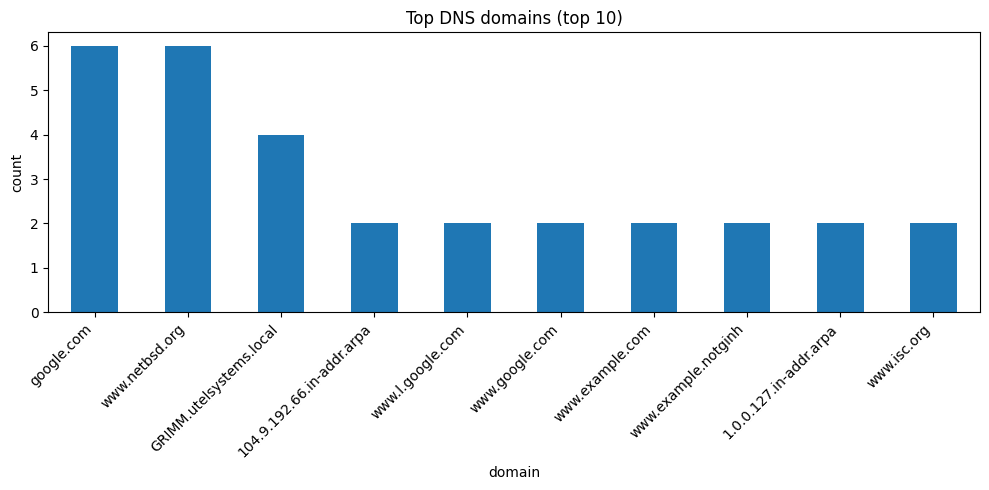

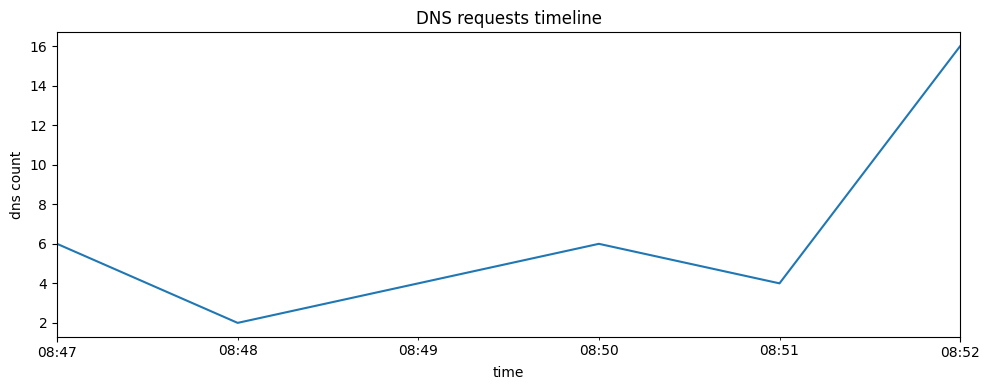

Отчет сохранен: analysis_results/forensic_report.txt


In [2]:
!apt-get update -qq
!apt-get install -y -qq tshark
!pip -q install pyshark pandas matplotlib nest_asyncio

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import pyshark
import nest_asyncio

nest_asyncio.apply()

RESULTS_DIR = "analysis_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

PCAP_FILE = None

if PCAP_FILE is None:
    candidates = []
    candidates += glob.glob("*.pcap")
    candidates += glob.glob("*.pcapng")
    candidates += glob.glob("*.cap")

    if not candidates:
        raise FileNotFoundError(
            "Не найден ни один файл .pcap/.pcapng/.cap в текущей папке. "
            "Загрузи дамп в Colab (Files) и перезапусти."
        )
    PCAP_FILE = candidates[0]

print("Используем файл:", PCAP_FILE)

dns_rows = []

cap = pyshark.FileCapture(
    PCAP_FILE,
    display_filter="dns",
    keep_packets=False,
)

for pkt in cap:
    try:
        t = getattr(pkt, "sniff_time", None)

        domain = None
        if hasattr(pkt, "dns") and hasattr(pkt.dns, "qry_name"):
            domain = str(pkt.dns.qry_name)

        src_ip = None
        dst_ip = None
        if hasattr(pkt, "ip"):
            src_ip = pkt.ip.src
            dst_ip = pkt.ip.dst
        elif hasattr(pkt, "ipv6"):
            src_ip = pkt.ipv6.src
            dst_ip = pkt.ipv6.dst

        if domain:
            dns_rows.append({
                "time": pd.to_datetime(t) if t is not None else pd.NaT,
                "domain": domain,
                "src_ip": src_ip,
                "dst_ip": dst_ip,
            })
    except Exception:
        continue

cap.close()

df_dns = pd.DataFrame(dns_rows)

print("DNS записей найдено:", len(df_dns))
if len(df_dns) > 0:
    display(df_dns.head(10))


dns_csv = os.path.join(RESULTS_DIR, "dns_requests.csv")
df_dns.to_csv(dns_csv, index=False)
print("Сохранено:", dns_csv)

plots_done = []

if len(df_dns) > 0:

    top_domains = df_dns["domain"].value_counts().head(10)
    plt.figure(figsize=(10, 5))
    top_domains.plot(kind="bar")
    plt.xlabel("domain")
    plt.ylabel("count")
    plt.title("Top DNS domains (top 10)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    top_domains_png = os.path.join(RESULTS_DIR, "top_domains.png")
    plt.savefig(top_domains_png, dpi=150)
    plt.show()
    plots_done.append(top_domains_png)

    # График 2: DNS по времени (если есть время)
    if df_dns["time"].notna().any():
        df_dns2 = df_dns.dropna(subset=["time"]).copy()
        df_dns2["minute"] = df_dns2["time"].dt.floor("min")
        dns_by_time = df_dns2.groupby("minute").size()

        plt.figure(figsize=(10, 4))
        dns_by_time.plot()
        plt.xlabel("time")
        plt.ylabel("dns count")
        plt.title("DNS requests timeline")
        plt.tight_layout()

        timeline_png = os.path.join(RESULTS_DIR, "dns_timeline.png")
        plt.savefig(timeline_png, dpi=150)
        plt.show()
        plots_done.append(timeline_png)

else:
    print("DNS не найден по фильтру dns. Это нормально, если дамп не про DNS.")

report_path = os.path.join(RESULTS_DIR, "forensic_report.txt")

with open(report_path, "w", encoding="utf-8") as f:
    f.write("Forensic report (network pcap)\n")
    f.write(f"Source file: {PCAP_FILE}\n\n")

    f.write(f"DNS records found: {len(df_dns)}\n")
    if len(df_dns) > 0:
        f.write("\nTop domains:\n")
        for dom, cnt in df_dns["domain"].value_counts().head(10).items():
            f.write(f"- {dom}: {cnt}\n")

        f.write("\nTop src IP:\n")
        if df_dns["src_ip"].notna().any():
            for ip, cnt in df_dns["src_ip"].value_counts().head(10).items():
                f.write(f"- {ip}: {cnt}\n")
        else:
            f.write("- src_ip not found in packets\n")

        f.write("\nTop dst IP:\n")
        if df_dns["dst_ip"].notna().any():
            for ip, cnt in df_dns["dst_ip"].value_counts().head(10).items():
                f.write(f"- {ip}: {cnt}\n")
        else:
            f.write("- dst_ip not found in packets\n")

    f.write("\nSaved artifacts:\n")
    f.write(f"- {dns_csv}\n")
    for p in plots_done:
        f.write(f"- {p}\n")

print("Отчет сохранен:", report_path)